# Experiment 6 — boosting-round convergence

**Question / hypothesis.** Did Experiment 5 stop because of its 1,200-tree search cap, and can lower learning rates with more rounds improve ranking robustly?

**Held constant.** Experiment 4 features, Experiment 5 tree structures, exact five folds, and all other model parameters remain fixed.

**Changed.** Only learning rate and maximum boosting rounds vary. Every fold uses AUC early stopping with 150-round patience.

The decision considers fold-best iterations, cap-hitting, component gains, simple blend weights, paired uncertainty, and whether E6 changes rankings rather than calibration alone.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
lgb = pd.read_csv(ROOT / 'reports/lightgbm_convergence.csv')
xgb = pd.read_csv(ROOT / 'reports/xgboost_convergence.csv')
blends = pd.read_csv(ROOT / 'reports/convergence_blend_results.csv')
analysis = json.loads((ROOT / 'reports/convergence_analysis.json').read_text())

The full study is reproducible with `uv run analyze-convergence`. Completed schedules and OOF vectors are checkpointed because the six requested schedules fit up to 5,000 rounds per fold.

## Schedule results and stopping rounds

In [2]:
columns = [
    'schedule', 'oof_auc', 'delta_vs_e5_component', 'mean_fold_auc', 'std_fold_auc',
    'fold_1_auc', 'fold_2_auc', 'fold_3_auc', 'fold_4_auc', 'fold_5_auc',
    'fold_1_best_iteration', 'fold_2_best_iteration', 'fold_3_best_iteration',
    'fold_4_best_iteration', 'fold_5_best_iteration', 'mean_best_iteration',
    'median_best_iteration', 'folds_without_full_stopping_window', 'fit_seconds'
]
lgb[columns].style.format({c: '{:.6f}' for c in columns if 'auc' in c or c.startswith('delta')})

,schedule,oof_auc,delta_vs_e5_component,mean_fold_auc,std_fold_auc,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc,fold_1_best_iteration,fold_2_best_iteration,fold_3_best_iteration,fold_4_best_iteration,fold_5_best_iteration,mean_best_iteration,median_best_iteration,folds_without_full_stopping_window,fit_seconds
0,lr_005_max_2500,0.963321,0.000097,0.963322,0.000731,0.962318,0.963265,0.963703,0.964275,0.963048,1502,1802,1641,1719,1198,1572.400000,1641.000000,0,140.036046
1,lr_003_max_3500,0.963379,0.000156,0.963386,0.000653,0.962529,0.963192,0.963764,0.964254,0.963194,3173,2306,2165,2772,2730,2629.200000,2730.000000,0,221.341334
2,lr_002_max_5000,0.963424,0.000201,0.963428,0.000667,0.962511,0.963319,0.963778,0.964302,0.963233,3960,4563,3599,3535,3808,3893.000000,3808.000000,0,322.259347


In [3]:
xgb[columns].style.format({c: '{:.6f}' for c in columns if 'auc' in c or c.startswith('delta')})

,schedule,oof_auc,delta_vs_e5_component,mean_fold_auc,std_fold_auc,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc,fold_1_best_iteration,fold_2_best_iteration,fold_3_best_iteration,fold_4_best_iteration,fold_5_best_iteration,mean_best_iteration,median_best_iteration,folds_without_full_stopping_window,fit_seconds
0,lr_005_max_2500,0.963930,0.000226,0.963933,0.000530,0.963260,0.963896,0.964131,0.964689,0.963690,1793,1848,1828,1689,1822,1796.000000,1822.000000,0,206.973182
1,lr_003_max_3500,0.963955,0.000250,0.963955,0.000560,0.963311,0.963891,0.964137,0.964794,0.963642,2821,2901,2888,2944,2627,2836.200000,2888.000000,0,311.171704
2,lr_002_max_5000,0.963991,0.000286,0.963992,0.000571,0.963310,0.964069,0.964108,0.964828,0.963647,4579,4720,4151,4944,4765,4631.800000,4720.000000,1,502.475133


Both families improve monotonically as the rate falls and round allowance grows. Every LightGBM fold completes its full stopping window. XGBoost 0.02 is partially cap-limited: fold 4 peaks at 4,944, only 56 rounds before the 5,000 cap, less than the 150-round patience.

## E6 blend weights

In [4]:
blends.style.format('{:.6f}')

,lightgbm_weight,xgboost_weight,oof_auc,log_loss,delta_vs_e5_blend
0,0.000000,1.000000,0.963991,0.219434,0.000047
1,0.100000,0.900000,0.964133,0.219016,0.000190
2,0.200000,0.800000,0.964228,0.218762,0.000285
3,0.300000,0.700000,0.964280,0.218647,0.000337
4,0.400000,0.600000,0.964289,0.218659,0.000346
5,0.500000,0.500000,0.964256,0.218792,0.000312
6,0.600000,0.400000,0.964179,0.219043,0.000236
7,0.700000,0.300000,0.964060,0.219409,0.000116
8,0.800000,0.200000,0.963895,0.219894,-0.000048
9,0.900000,0.100000,0.963684,0.220503,-0.000259


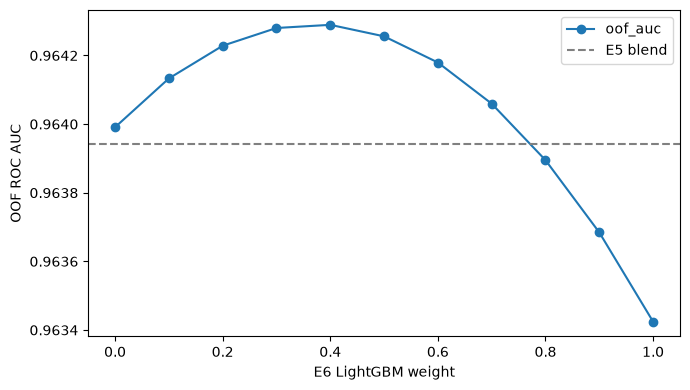

In [5]:
ax = blends.plot(x='lightgbm_weight', y='oof_auc', marker='o', legend=False, figsize=(7, 4))
ax.axhline(0.9639433758194731, color='gray', linestyle='--', label='E5 blend')
ax.set(xlabel='E6 LightGBM weight', ylabel='OOF ROC AUC')
ax.legend()
plt.tight_layout()

The numerical optimum is the simple 40/60 LightGBM/XGBoost blend at 0.964289. Its 30/70 and 50/50 neighbors are within 0.000034, so the optimum is broad rather than fragile.

## Paired uncertainty and E5/E6 diversity

In [6]:
analysis['bootstrap_vs_e5_blend']

{'mean': 0.0003466170546687708,
 'ci_95_lower': 0.0003081752385138886,
 'ci_95_upper': 0.0003873291142884538,
 'proportion_positive': 1.0,
 'n_resamples': 500,
 'seed': 42}

In [7]:
diversity = analysis['prediction_diversity']
pd.DataFrame({
    name: {
        'Pearson': values['pearson_correlation'],
        'Spearman': values['spearman_correlation'],
        'Mean absolute difference': values['mean_absolute_probability_difference'],
        'Class disagreement': values['class_disagreement_rate'],
    } for name, values in diversity.items()
}).T

,Pearson,Spearman,Mean absolute difference,Class disagreement
lightgbm_e5_vs_e6,0.998285,0.997799,0.010476,0.010852
xgboost_e5_vs_e6,0.997355,0.998054,0.013773,0.013985
blend_e5_vs_e6,0.998602,0.998665,0.010065,0.010160


## Conclusion

Both families improve monotonically as learning rate falls and the round allowance grows. LightGBM converges within every cap; one 0.02 XGBoost fold remains partially cap-limited, so convergence is not claimed universally. E6 changes rankings slightly—not calibration alone—and the 40/60 blend reaches **0.964289 OOF AUC**, +0.000346 over E5, with a paired 95% interval of [0.000308, 0.000387].

**Promoted:** 40% LightGBM / 60% XGBoost using median fold-best rounds for full-data fitting. The public score was recorded only after this OOF decision.